# Task 2 -- Exploratory Data Analysis & Data Characterisation

Temporal, spatial and statistical exploration of the traffic matrix. Each figure is followed by an interpretation cell -- **replace the bracketed prompts with observations from the real data** before submission.

In [1]:
# --- Project setup: make the `src` package importable from anywhere ---
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "src").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))
print(f"Project root: {_root}")

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


Project root: C:\Users\josue\Music\ml_tech_I\formative_1


In [2]:
from src.data_loading import (load_traffic_matrix, compute_area_totals,
                              resolve_target_areas, get_area_series)
matrix = load_traffic_matrix()
totals = compute_area_totals(matrix, save=False)
areas = resolve_target_areas(matrix)
print('matrix:', matrix.shape, '| areas:', areas)

matrix: (8784, 10000) | areas: {'highest': 5161, 'fixed_1': 4159, 'fixed_2': 4556}


## 2.I -- Probability density function of per-area traffic

,value
n_areas,1.000000e+04
mean,5.499728e+05
median,2.747062e+05
std,8.861689e+05
min,2.136265e+02
max,1.268267e+07
skewness,4.277662e+00
kurtosis,2.565683e+01
p95 / median ratio,7.827681e+00


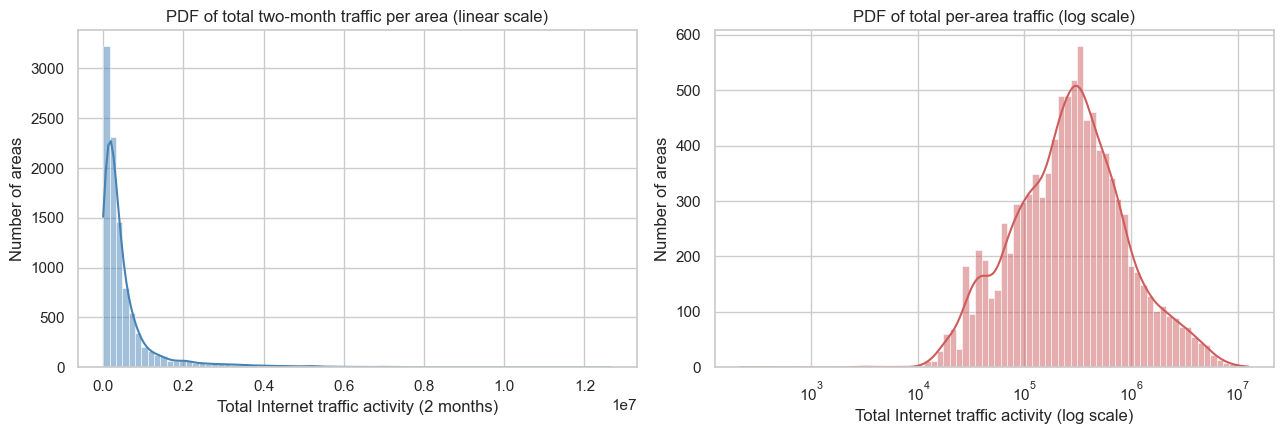

In [3]:
from src.eda import plot_traffic_pdf, traffic_distribution_summary
display(traffic_distribution_summary(totals))
plot_traffic_pdf(totals)

**Interpretation.** The distribution is strongly right-skewed (skewness 4.28, excess kurtosis 25.7) and looks roughly log-normal on the log axis. The mean (549,973) is about twice the median (274,706) and the p95/median ratio is ~7.8 -- most areas carry modest traffic while a small number of central cells dominate. The busiest area carries about 59,000x the quietest, which fits a typical city: dense business / commercial districts produce far more mobile data than peripheral residential cells.

## 2.II -- Time series of the three target areas (first two weeks)

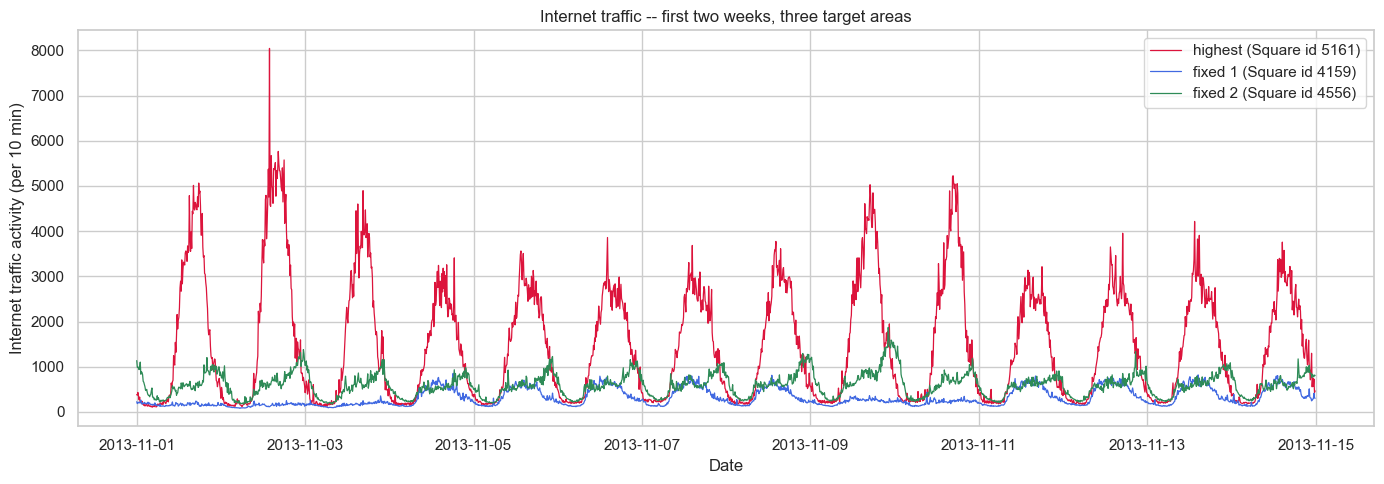

In [4]:
from src.eda import plot_area_timeseries
plot_area_timeseries(matrix, areas)

**Interpretation.** All three areas show the same daily cycle (low overnight, peaks during the day) and a visible weekday/weekend contrast. They differ mainly in amplitude: the highest-traffic area 5161 (Milan city centre) peaks at ~5,000-8,000 with tall sharp daytime peaks; area 4556 is intermediate (~1,000-2,000); area 4159 is the quietest (~500-1,500) with a flatter profile. The differences plausibly reflect land use -- an intensely visited centre versus quieter, more residential cells.

## 2.III -- Stationarity: rolling statistics + ADF test

,adf_statistic,p_value,used_lag,n_obs,crit_1%,crit_5%,crit_10%,stationary_at_5%
series,,,,,,,,
highest (area 5161),-19.130738,0.000000e+00,36,8747,-3.431098,-2.86187,-2.566946,True
fixed_1 (area 4159),-12.965623,3.158047e-24,36,8747,-3.431098,-2.86187,-2.566946,True
fixed_2 (area 4556),-14.265213,1.404409e-26,20,8763,-3.431096,-2.86187,-2.566946,True


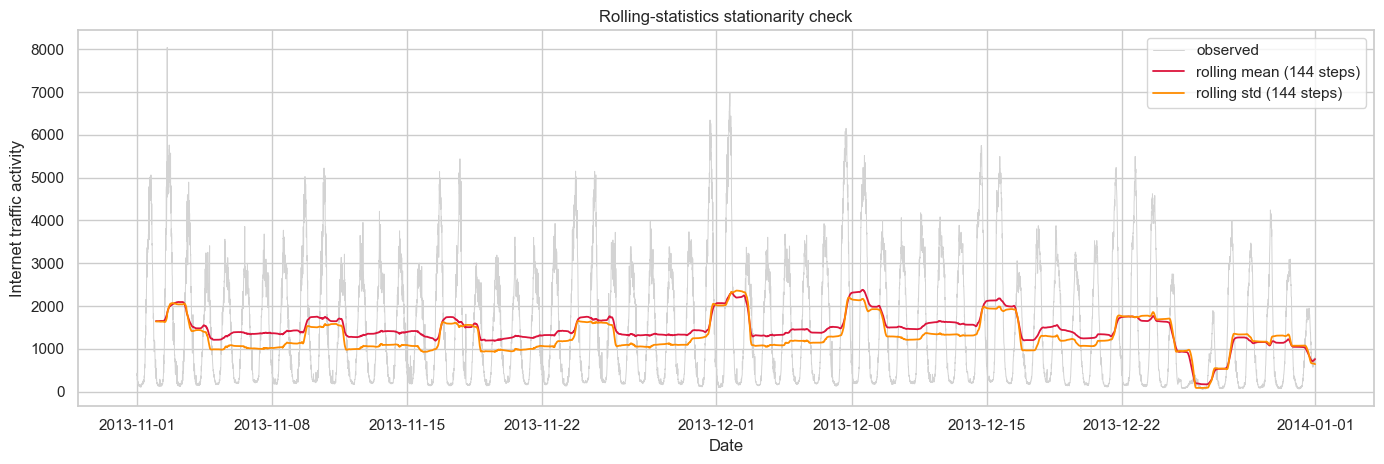

In [5]:
from src.eda import plot_stationarity, adf_test
ref_id = areas['highest']
ref = get_area_series(matrix, ref_id)
adf = pd.DataFrame([adf_test(get_area_series(matrix, sid),
                             name=f'{lab} (area {sid})')
                    for lab, sid in areas.items()]).set_index('series')
display(adf)
plot_stationarity(ref)

**Interpretation.** The ADF statistics (-19.13 for area 5161, -12.97 for 4159, -14.27 for 4556) are all far below the 1% critical value of -3.43, so the unit-root null is firmly rejected -- the series are stationary in the mean. The rolling standard deviation oscillates strongly with the daily cycle though, which means the series is seasonal even though it has no trend. That tells SARIMA to use seasonal differencing (D = 1) at period 144 and NOT ordinary differencing (d = 0).

## 2.IV -- Seasonal decomposition (trend / seasonal / residual)

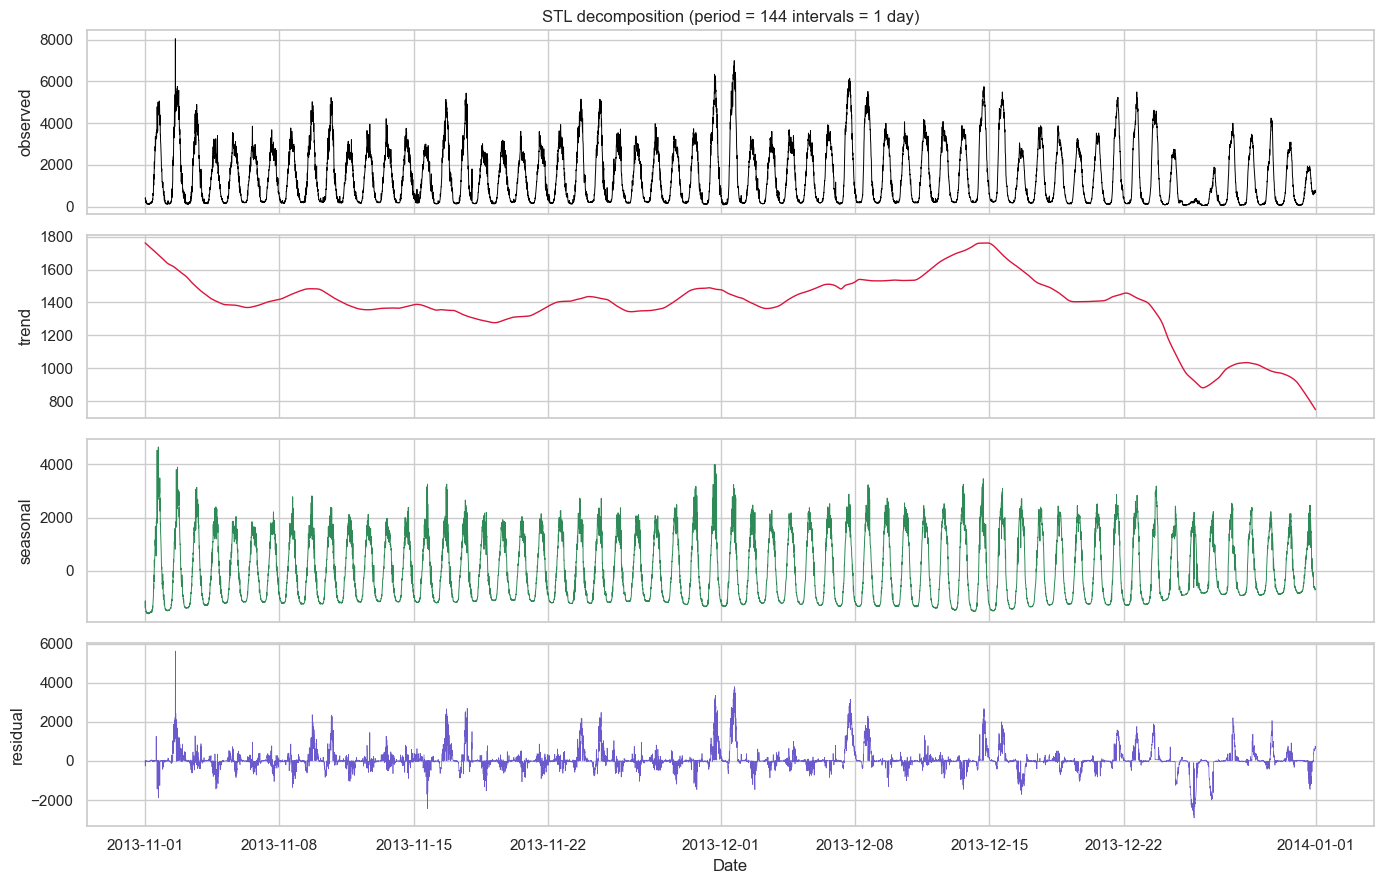

In [6]:
from src.eda import decompose_series
fig, dec = decompose_series(ref)
fig

**Interpretation.** The seasonal component dominates the variation (amplitude roughly +/- 2,000-4,000) and captures the 24-hour shape. The trend stays modest (~700 to ~1,800) for most of the period but drops noticeably in the last week of December, the Christmas / New Year holiday period. Residuals are small most of the time but burst upward around anomalies. A secondary weekly pattern is visible: the daily peaks are smaller on weekends.

## 2.V -- Autocorrelation & partial autocorrelation

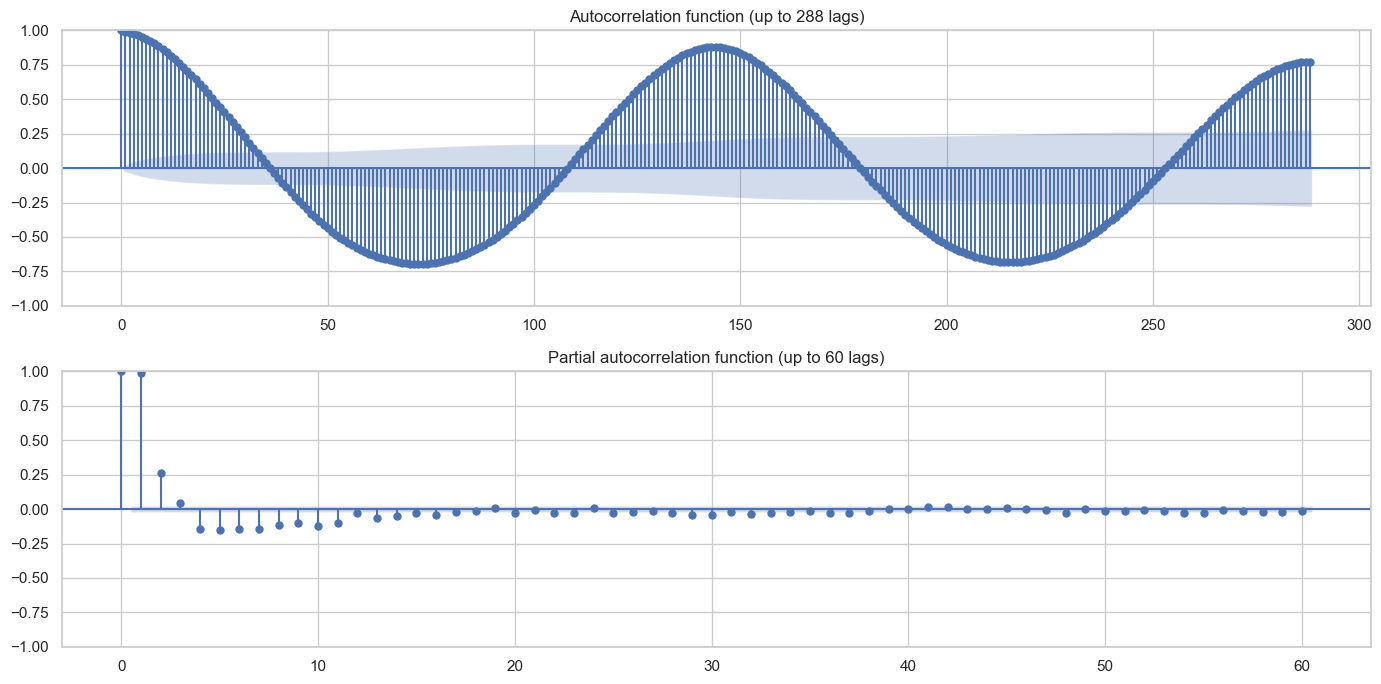

In [7]:
from src.eda import plot_acf_pacf
plot_acf_pacf(ref)

**Interpretation.** The ACF is a near-perfect damped sinusoid with peaks at lag 144 (~0.88) and lag 288 (~0.78) and deep troughs near lag 72 and 216 -- the classic signature of a 24-hour seasonal cycle. The PACF has 2-3 large early lags then cuts off, indicating an AR(2)-ish short-range structure. Together this justifies the SARIMA setup in Task 3: seasonal differencing at period 144 to remove the daily cycle, then a small ARIMA(p, d, q) on the residual -- I picked (2, 0, 2).

## 2.VI -- Spatial analysis (heatmap)

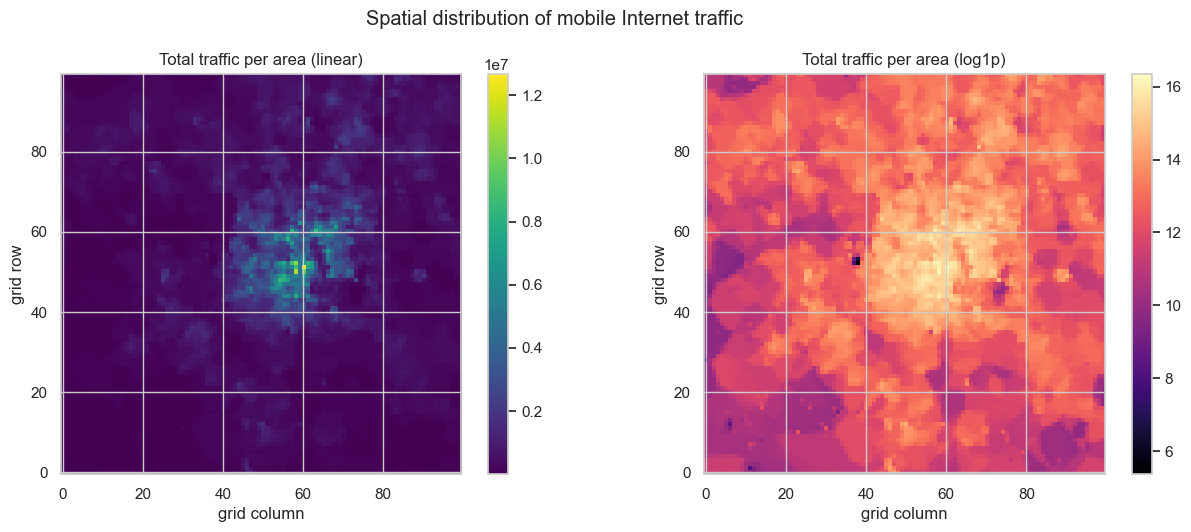

In [8]:
from src.eda import plot_spatial_heatmap
plot_spatial_heatmap(totals)

**Interpretation.** Traffic is highly concentrated. On the linear-scale map almost everything is dark except for a compact bright core around grid rows 45-70, columns 45-80 -- the Milan city centre, containing the peak area 5161 (the Duomo/centro area). The log-scale map shows the structure better: a smooth radial decay from the centre, a few warmer secondary patches that look like transport/commercial sub-centres, and isolated very dark cells (e.g. near row 52, col 38) that are probably low-activity land such as parks. This is the spatial side of the same heavy-tailed pattern we saw in the PDF.

## 2.VII -- Anomalies & unusual behaviour

,timestamp,value,expected,robust_z
0,2013-11-18 00:50:00,1809.570435,247.854507,34.906272
1,2013-11-25 01:50:00,914.645203,180.573349,22.520766
2,2013-11-15 04:00:00,834.699646,181.189056,19.981078
3,2013-11-18 00:30:00,1275.561157,297.680664,18.198408
4,2013-11-18 00:40:00,906.141785,232.739960,16.028821
5,2013-11-15 05:30:00,591.300659,187.163818,11.962027
6,2013-11-15 02:30:00,564.851196,189.966309,10.932503
7,2013-11-25 02:00:00,620.068665,209.117111,10.886776
8,2013-11-03 02:20:00,604.864563,209.691818,10.440078
9,2013-12-06 23:40:00,1177.328735,440.835297,9.255306


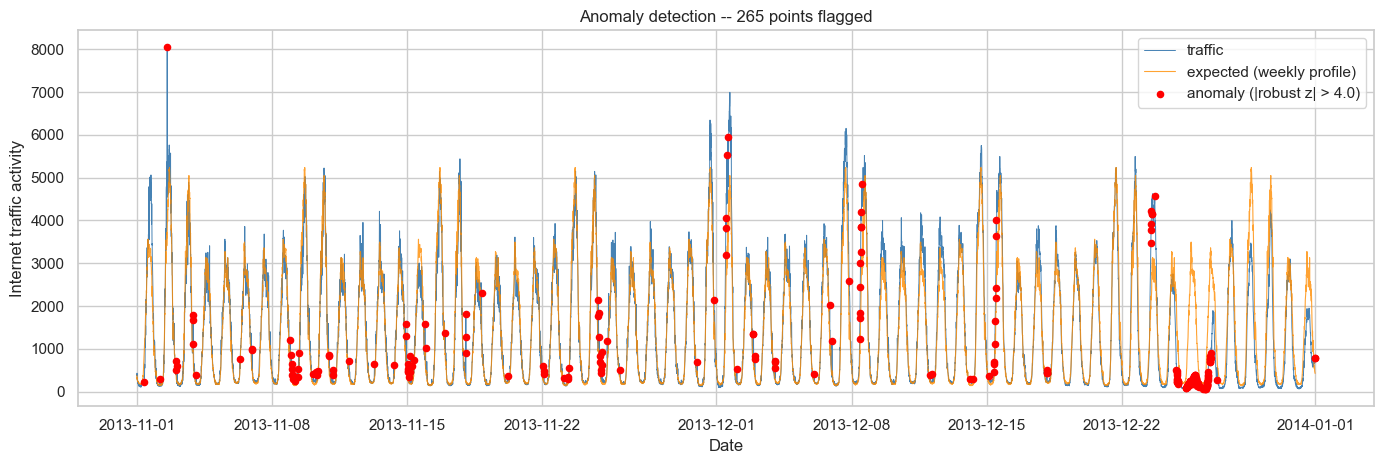

In [9]:
from src.eda import detect_anomalies
fig, anomalies = detect_anomalies(ref)
display(anomalies.head(10))
fig

**Interpretation.** 265 points are flagged (~3% of the series). They fall into two main groups: (1) sharp late-night spikes in mid-November (e.g. 18 Nov 00:50 has traffic ~1,810 vs an expected ~248 -- a robust z of ~35), probably nightlife events or measurement bursts; and (2) a dense cluster at the end of December where traffic drops well below the expected weekly profile -- the Christmas / New Year holiday slowdown. The 8 December (Italian Immaculate Conception holiday) is also flagged. These matter because the Task 3 test week (16-22 December) overlaps the start of the holiday period, so the forecasting models will probably struggle there.